   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
Accuracy: 1.000
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


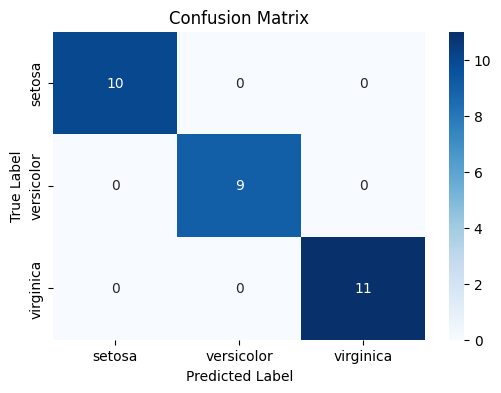

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
iris=load_iris()
df=pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target']=iris.target
print(df.head())
X = df.drop('target',axis=1)
y=df['target']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
sgd_clf=SGDClassifier(max_iter=1000, tol=1e-3)
sgd_clf.fit(X_train,y_train)
y_pred=sgd_clf.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy:.3f}")
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.calibration import CalibratedClassifierCV  # optional for probabilities
import warnings
warnings.filterwarnings("ignore")

In [3]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)  # 0 = malignant, 1 = benign
print("Dataset:", data.DESCR.splitlines()[0])
print("X shape:", X.shape, "y shape:", y.shape)
print()

Dataset: .. _breast_cancer_dataset:
X shape: (569, 30) y shape: (569,)



In [4]:
print("First 5 rows:")
print(X.iloc[:, :6].head())

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  
0           0.27760  
1           0.07864  
2           0.15990  
3           0.28390  
4           0.13280  


In [5]:
feat1, feat2 = "mean radius", "mean texture"
X_vis = X[[feat1, feat2]].values

X_full = X.values

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.25, random_state=42, stratify=y)
Xv_train, Xv_test, yv_train, yv_test = train_test_split(X_vis, y, test_size=0.25, random_state=42, stratify=y)


In [7]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

scaler_vis = StandardScaler().fit(Xv_train)
Xv_train_s = scaler_vis.transform(Xv_train)
Xv_test_s = scaler_vis.transform(Xv_test)

In [8]:
clf = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=1e-4,
    max_iter=1000,
    tol=1e-4,
    learning_rate='optimal',
    random_state=42,
    verbose=0
)

clf.fit(X_train_s, y_train)


calibrated = CalibratedClassifierCV(clf, method="sigmoid", cv=5)
calibrated.fit(X_train_s, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=SGDClassifier(loss='log_loss', random_state=42,
                                               tol=0.0001))

In [9]:
y_pred = clf.predict(X_test_s)
y_proba = calibrated.predict_proba(X_test_s)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Test set metrics:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print()

Test set metrics:
Accuracy:  0.9650
Precision: 0.9670
Recall:    0.9778
F1-score:  0.9724



In [10]:
cv_scores = cross_val_score(clf, scaler.transform(X_full), y, cv=5, scoring='accuracy')
print("5-fold CV accuracy: mean={:.4f} std={:.4f}".format(cv_scores.mean(), cv_scores.std()))
print()

5-fold CV accuracy: mean=0.9631 std=0.0128



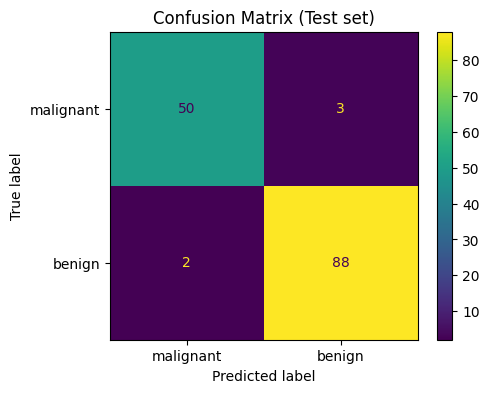

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax)
ax.set_title("Confusion Matrix (Test set)")
plt.show()

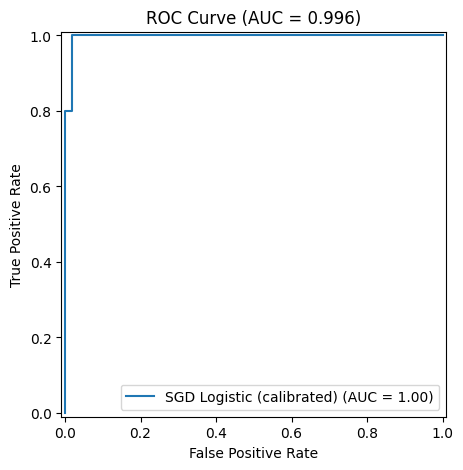

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(6,5))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="SGD Logistic (calibrated)").plot(ax=ax)
ax.set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.show()

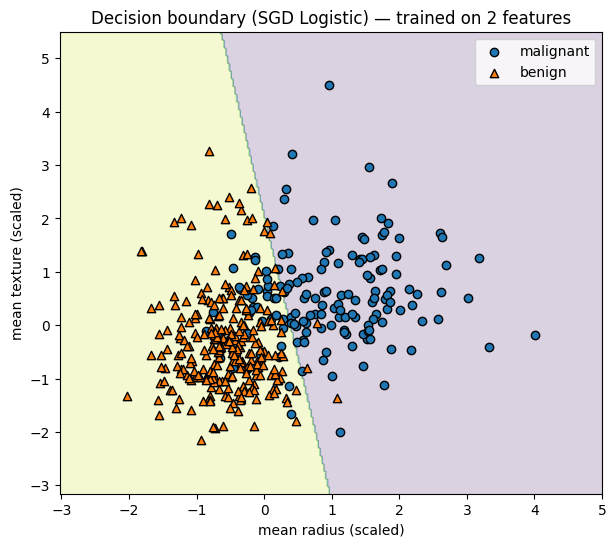

In [13]:
clf_vis = SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-4, random_state=42)
clf_vis.fit(Xv_train_s, yv_train)

xx_min, xx_max = Xv_train_s[:, 0].min() - 1, Xv_train_s[:, 0].max() + 1
yy_min, yy_max = Xv_train_s[:, 1].min() - 1, Xv_train_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(xx_min, xx_max, 300), np.linspace(yy_min, yy_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

Z = clf_vis.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7,6))
ax.contourf(xx, yy, Z, alpha=0.2)

ax.scatter(Xv_train_s[:, 0][yv_train==0], Xv_train_s[:, 1][yv_train==0], marker='o', label=data.target_names[0], edgecolor='k')
ax.scatter(Xv_train_s[:, 0][yv_train==1], Xv_train_s[:, 1][yv_train==1], marker='^', label=data.target_names[1], edgecolor='k')
ax.set_xlabel(feat1 + " (scaled)")
ax.set_ylabel(feat2 + " (scaled)")
ax.set_title("Decision boundary (SGD Logistic) — trained on 2 features")
ax.legend()
plt.show()
